# Backtest 006 — Smart Money Flow Cloud Strategy

Python port of **Smart Money Flow Cloud [BOSWaves]** used as a standalone trading strategy.

## Signal logic

| Signal | Condition | Usage |
|--------|-----------|-------|
| `switch_up` | Close crosses **above** adaptive upper band → state turns bullish | Primary entry |
| `bull_dot` | Price retests basis from below while state = bullish | Secondary entry (with cooldown) |
| `switch_down` | Close crosses **below** adaptive lower band → state turns bearish | Explicit exit |
| ATR trailing | `atr_trailing_nb` from backend | Fallback exit / SL |

Stop-loss is placed at the lowest low of the past `low_stop_lookback` bars relative to entry.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb

plt.style.use('dark_background')
print('imports ok')


imports ok


## 1. Load Data

In [2]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)
    dt  = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks

local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake ...')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} -> {close.index[-1]}')
close.tail(3)


Loading from local HDF5: stocks_data_latest.h5
Shape: (2500, 198)  |  2016-04-04 00:00:00 -> 2026-04-03 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-01,7.08,14.7,23.799999,46.900002,8.63,13.00,14.90,23.85,5.59,5.72,...,1705.739990,61.299999,12.80,26.799999,4.24,58.400002,27.549999,24.250000,99.400002,10.15
2026-04-02,7.00,14.5,23.600000,46.400002,8.56,12.85,14.65,23.75,5.55,5.64,...,1695.130005,60.799999,12.65,26.250000,4.15,58.200001,27.200001,24.299999,98.300003,10.00
2026-04-03,6.94,14.5,23.500000,45.799999,8.54,12.55,14.60,23.60,5.53,5.59,...,1684.089966,60.000000,12.50,25.799999,4.02,58.000000,26.500000,23.799999,93.599998,9.94


## 2. Smart Money Flow Cloud Indicator

In [3]:
def _alma_1d(series: np.ndarray, period: int, offset: float, sigma: float) -> np.ndarray:
    """Arnaud Legoux Moving Average (1-D numpy)."""
    m = offset * (period - 1)
    s = period / sigma
    w = np.exp(-((np.arange(period) - m) ** 2) / (2 * s * s))
    w /= w.sum()
    out = np.full(len(series), np.nan)
    for i in range(period - 1, len(series)):
        out[i] = np.dot(w, series[i - period + 1 : i + 1])
    return out


def smart_money_flow_cloud(
    open_df:  pd.DataFrame,
    high_df:  pd.DataFrame,
    low_df:   pd.DataFrame,
    close_df: pd.DataFrame,
    vol_df:   pd.DataFrame,
    trend_len:    int   = 34,
    basis_type:   str   = 'EMA',
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    mf_len:       int   = 24,
    mf_smooth:    int   = 5,
    mf_power:     float = 1.2,
    atr_len:      int   = 14,
    min_mult:     float = 0.9,
    max_mult:     float = 2.2,
    dot_cooldown: int   = 12,
) -> dict:
    """Returns per-symbol dict with all SMF Cloud series."""
    results = {}
    syms = close_df.columns

    for sym in syms:
        o = open_df[sym].values.astype(np.float64)
        h = high_df[sym].values.astype(np.float64)
        l = low_df[sym].values.astype(np.float64)
        c = close_df[sym].values.astype(np.float64)
        v = vol_df[sym].values.astype(np.float64)
        n   = len(c)
        idx = close_df.index

        # Basis
        if basis_type == 'ALMA':
            raw_o = _alma_1d(o, trend_len, alma_offset, alma_sigma)
            raw_c = _alma_1d(c, trend_len, alma_offset, alma_sigma)
        else:
            raw_o = pd.Series(o, index=idx).ewm(span=trend_len, adjust=False).mean().values
            raw_c = pd.Series(c, index=idx).ewm(span=trend_len, adjust=False).mean().values
        if basis_smooth > 1:
            b_o = pd.Series(raw_o, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
            b_c = pd.Series(raw_c, index=idx).ewm(span=basis_smooth, adjust=False).mean().values
        else:
            b_o, b_c = raw_o, raw_c
        b_main = b_c

        # Smart Money Flow
        hl      = h - l
        clv     = np.where(hl == 0, 0.0, ((c - l) - (h - c)) / hl)
        raw_flow = clv * v
        mf_num  = pd.Series(raw_flow, index=idx).rolling(mf_len).sum().values
        mf_den  = pd.Series(np.abs(raw_flow), index=idx).rolling(mf_len).sum().values
        mf_raw  = np.where(mf_den == 0, 0.0, mf_num / mf_den)
        mf_sm   = (pd.Series(mf_raw, index=idx).ewm(span=mf_smooth, adjust=False).mean().values
                   if mf_smooth > 1 else mf_raw)
        strength = np.clip(np.power(np.abs(mf_sm), mf_power), 0.0, 1.0)
        mult     = min_mult + (max_mult - min_mult) * strength

        # Adaptive bands
        atr    = talib.ATR(h, l, c, timeperiod=atr_len)
        upper  = b_main + atr * mult
        lower  = b_main - atr * mult

        # State machine
        long_cond  = (np.roll(c, 1) <= np.roll(upper, 1)) & (c > upper)
        short_cond = (np.roll(c, 1) >= np.roll(lower, 1)) & (c < lower)
        long_cond[0] = short_cond[0] = False
        last_sig    = np.zeros(n, dtype=np.int8)
        last_sig[0] = 1 if c[0] >= b_main[0] else -1
        for i in range(1, n):
            if long_cond[i]:    last_sig[i] =  1
            elif short_cond[i]: last_sig[i] = -1
            else:               last_sig[i] = last_sig[i - 1]

        switch_up   = (last_sig ==  1) & (np.roll(last_sig, 1) == -1)
        switch_down = (last_sig == -1) & (np.roll(last_sig, 1) ==  1)
        switch_up[0] = switch_down[0] = False

        # Retest dots with cooldown
        bear_cond = (last_sig == -1) & (h > b_c)
        bull_cond = (last_sig ==  1) & (l < b_c)
        bear_dot  = np.zeros(n, dtype=bool)
        bull_dot  = np.zeros(n, dtype=bool)
        last_bear = last_bull = -dot_cooldown - 1
        for i in range(n):
            if bear_cond[i] and (dot_cooldown == 0 or i - last_bear >= dot_cooldown):
                bear_dot[i] = True; last_bear = i
            if bull_cond[i] and (dot_cooldown == 0 or i - last_bull >= dot_cooldown):
                bull_dot[i] = True; last_bull = i

        # Trend strength (tanh-scaled)
        mintick = 0.01
        up_span = np.maximum(upper - b_main, mintick)
        dn_span = np.maximum(b_main - lower, mintick)
        raw_str = np.where(last_sig == 1,
                           (c - b_main) / up_span,
                           -(b_main - c) / dn_span)
        x       = np.clip(raw_str * 1.5, -10, 10)
        v_tanh  = (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
        str_signed = pd.Series(v_tanh, index=idx).ewm(span=3, adjust=False).mean().values

        results[sym] = {
            'b_open':          pd.Series(b_o,         index=idx),
            'b_close':         pd.Series(b_c,         index=idx),
            'upper':           pd.Series(upper,        index=idx),
            'lower':           pd.Series(lower,        index=idx),
            'mf_smooth':       pd.Series(mf_sm,        index=idx),
            'strength':        pd.Series(strength,     index=idx),
            'mult':            pd.Series(mult,         index=idx),
            'last_signal':     pd.Series(last_sig,     index=idx),
            'switch_up':       pd.Series(switch_up,    index=idx),
            'switch_down':     pd.Series(switch_down,  index=idx),
            'bull_dot':        pd.Series(bull_dot,     index=idx),
            'bear_dot':        pd.Series(bear_dot,     index=idx),
            'strength_signed': pd.Series(str_signed,   index=idx),
        }

    return results


print('smart_money_flow_cloud() defined')


smart_money_flow_cloud() defined


## 3. Strategy Signal Builder

In [4]:
def smf_to_df(smf: dict, field: str) -> pd.DataFrame:
    """Stack a single SMF field across all symbols into (date x symbol) DataFrame."""
    return pd.DataFrame({sym: smf[sym][field] for sym in smf})


def compute_smf_signals(
    open_df, high_df, low_df, close_df, vol_df,
    trend_len:    int   = 34,
    basis_type:   str   = 'EMA',
    alma_offset:  float = 0.85,
    alma_sigma:   float = 6.0,
    basis_smooth: int   = 3,
    mf_len:       int   = 24,
    mf_smooth:    int   = 5,
    mf_power:     float = 1.2,
    atr_len:      int   = 14,
    min_mult:     float = 0.9,
    max_mult:     float = 2.2,
    dot_cooldown: int   = 12,
    entry_mode:   str   = 'switch',   # 'switch' | 'retest' | 'both'
    min_strength: float = 0.0,        # minimum flow strength [0,1] at entry
    mf_positive:  bool  = False,      # require mf_smooth > 0 at entry
):
    """
    Returns (entries_df, exits_df, smf).

    Entry modes:
      'switch' -- buy on switch_up (state turns bullish)
      'retest' -- buy on bull_dot (price touches basis in bull regime)
      'both'   -- switch_up OR bull_dot
    """
    smf = smart_money_flow_cloud(
        open_df, high_df, low_df, close_df, vol_df,
        trend_len=trend_len, basis_type=basis_type,
        alma_offset=alma_offset, alma_sigma=alma_sigma, basis_smooth=basis_smooth,
        mf_len=mf_len, mf_smooth=mf_smooth, mf_power=mf_power,
        atr_len=atr_len, min_mult=min_mult, max_mult=max_mult,
        dot_cooldown=dot_cooldown,
    )
    switch_up   = smf_to_df(smf, 'switch_up')
    bull_dot    = smf_to_df(smf, 'bull_dot')
    switch_down = smf_to_df(smf, 'switch_down')
    strength    = smf_to_df(smf, 'strength')
    mf_sm       = smf_to_df(smf, 'mf_smooth')

    if entry_mode == 'switch':
        raw_entries = switch_up
    elif entry_mode == 'retest':
        raw_entries = bull_dot
    else:
        raw_entries = switch_up | bull_dot

    str_mask   = strength >= min_strength
    mf_mask    = (mf_sm > 0) if mf_positive else pd.DataFrame(
        True, index=mf_sm.index, columns=mf_sm.columns)
    entries_df = raw_entries & str_mask & mf_mask
    exits_df   = switch_down

    return entries_df, exits_df, smf


def compute_smf_exits(close, high, low, smf: dict,
                      atr_multiplier: float = 1.9,
                      atr_period:     int   = 10,
                      low_stop_lookback: int = 5):
    """
    Returns (atr_exits_df, sl_stop_df, lower_df).

    atr_exits_df : ATR trailing-stop crossings as fallback exit.
    sl_stop_df   : relative stop-loss at entry (lowest-low of last N bars).
    lower_df     : SMF lower band (reference for dynamic SL).
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period)
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'],
        param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl       = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    atr_exits_df = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    lower_df   = smf_to_df(smf, 'lower')
    return atr_exits_df, sl_stop_df, lower_df


print('Signal functions defined')


Signal functions defined


## 4. Baseline Run (default params, switch mode)

In [ ]:
print('Computing baseline SMF signals ...')
entries_base, exits_base_smf, smf_base = compute_smf_signals(
    open_, high, low, close, volume,
    trend_len=34, basis_smooth=3,
    mf_len=24, mf_smooth=5, mf_power=1.2,
    atr_len=14, min_mult=0.9, max_mult=2.2,
    dot_cooldown=12,
    entry_mode='switch', min_strength=0.0, mf_positive=False,
)
atr_exits_base, sl_stop_base, lower_base = compute_smf_exits(
    close, high, low, smf_base,
    atr_multiplier=1.9, atr_period=10, low_stop_lookback=5,
)
exits_base = atr_exits_base

pf_base = vbt.Portfolio.from_signals(
    close,
    entries   = entries_base,
    exits     = exits_base,
    sl_stop   = sl_stop_base,
    freq      = '1D',
    init_cash = 100_000,
    fees      = 0.001,
    slippage  = 0.001,
)
sv = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
so = pf_base.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'Baseline  |  Sharpe mean={sv.mean():.3f}  median={sv.median():.3f}  >1: {(sv>1).sum()}/{len(sv)}  |  Sortino mean={so.mean():.3f}')


Computing baseline SMF signals ...
Baseline  |  Sharpe mean=0.456  median=0.454  >1: 16/198  |  Sortino mean=0.703


## 5. Optuna Optimisation

Multi-objective: maximise **(Mean Total Return %, Mean Sortino Ratio)** using NSGA-II.


In [7]:
def make_smf_objective():
    def objective(trial):
        trend_len    = trial.suggest_int  ('trend_len',     10, 55)
        basis_smooth = trial.suggest_int  ('basis_smooth',   1,  5)
        mf_len       = trial.suggest_int  ('mf_len',        10, 40)
        mf_smooth    = trial.suggest_int  ('mf_smooth',      1, 10)
        mf_power     = trial.suggest_float('mf_power',      0.5, 2.5, step=0.1)
        atr_len      = trial.suggest_int  ('atr_len',        7, 21)
        min_mult     = trial.suggest_float('min_mult',       0.5, 1.5, step=0.1)
        max_mult     = trial.suggest_float('max_mult',       1.5, 3.5, step=0.1)
        dot_cooldown = trial.suggest_int  ('dot_cooldown',   5, 30)
        entry_mode   = trial.suggest_categorical('entry_mode', ['switch', 'retest', 'both'])
        min_strength = trial.suggest_float('min_strength',   0.0, 0.6, step=0.05)
        mf_positive  = trial.suggest_categorical('mf_positive', [True, False])
        atr_multiplier    = trial.suggest_float('atr_multiplier',     1.2, 3.0, step=0.1)
        atr_period        = trial.suggest_int  ('atr_period',          7, 21)
        low_stop_lookback = trial.suggest_int  ('low_stop_lookback',   3, 20)

        try:
            entries, exits_smf, smf = compute_smf_signals(
                open_, high, low, close, volume,
                trend_len=trend_len, basis_smooth=basis_smooth,
                mf_len=mf_len, mf_smooth=mf_smooth, mf_power=mf_power,
                atr_len=atr_len, min_mult=min_mult, max_mult=max_mult,
                dot_cooldown=dot_cooldown,
                entry_mode=entry_mode, min_strength=min_strength, mf_positive=mf_positive,
            )
            atr_exits, sl_stop, _ = compute_smf_exits(
                close, high, low, smf,
                atr_multiplier=atr_multiplier, atr_period=atr_period,
                low_stop_lookback=low_stop_lookback,
            )
            exits = exits_smf | atr_exits
            pf = vbt.Portfolio.from_signals(
                close,
                entries   = entries,
                exits     = exits,
                sl_stop   = sl_stop,
                freq      = '1D',
                init_cash = 100_000,
                fees      = 0.001,
                slippage  = 0.001,
            )
            tr = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            so = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            if len(tr) == 0 or len(so) == 0:
                return -1.0, -1.0
            return float(tr.mean() * 100), float(so.mean())
        except Exception:
            return -1.0, -1.0

    return objective


N_TRIALS = 300

study_smf = optuna.create_study(
    directions   = ['maximize', 'maximize'],
    sampler      = optuna.samplers.NSGAIISampler(seed=42),
    study_name   = 'smf_cloud_strategy',
)
study_smf.optimize(make_smf_objective(), n_trials=N_TRIALS, show_progress_bar=True)
print(f'Done — {len(study_smf.best_trials)} Pareto-optimal trials')


  0%|          | 0/300 [00:00<?, ?it/s]

Done — 300 Pareto-optimal trials


## 6. Select Best Parameters

In [8]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best_smf(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    all_v = np.array([t.values for t in study.best_trials])
    r_min, r_max = all_v[:, 0].min(), all_v[:, 0].max()
    s_min, s_max = all_v[:, 1].min(), all_v[:, 1].max()
    def score(t):
        r = (t.values[0] - r_min) / max(r_max - r_min, 1e-9)
        s = (t.values[1] - s_min) / max(s_max - s_min, 1e-9)
        return 0.4 * r + 0.6 * s
    return max(study.best_trials, key=score)


best_trial = pick_best_smf(study_smf)
best_p     = best_trial.params
print(f'Best trial #{best_trial.number} -- Return={best_trial.values[0]:.2f}%  Sortino={best_trial.values[1]:.3f}')
print('\nBest params:')
for k, v in best_p.items():
    print(f'  {k}: {v}')


Best trial #0 -- Return=-1.00%  Sortino=-1.000

Best params:
  trend_len: 27
  basis_smooth: 5
  mf_len: 32
  mf_smooth: 6
  mf_power: 0.8
  atr_len: 9
  min_mult: 0.5
  max_mult: 3.3
  dot_cooldown: 20
  entry_mode: both
  min_strength: 0.5
  mf_positive: True
  atr_multiplier: 1.5
  atr_period: 11
  low_stop_lookback: 12


## 7. Pareto Front

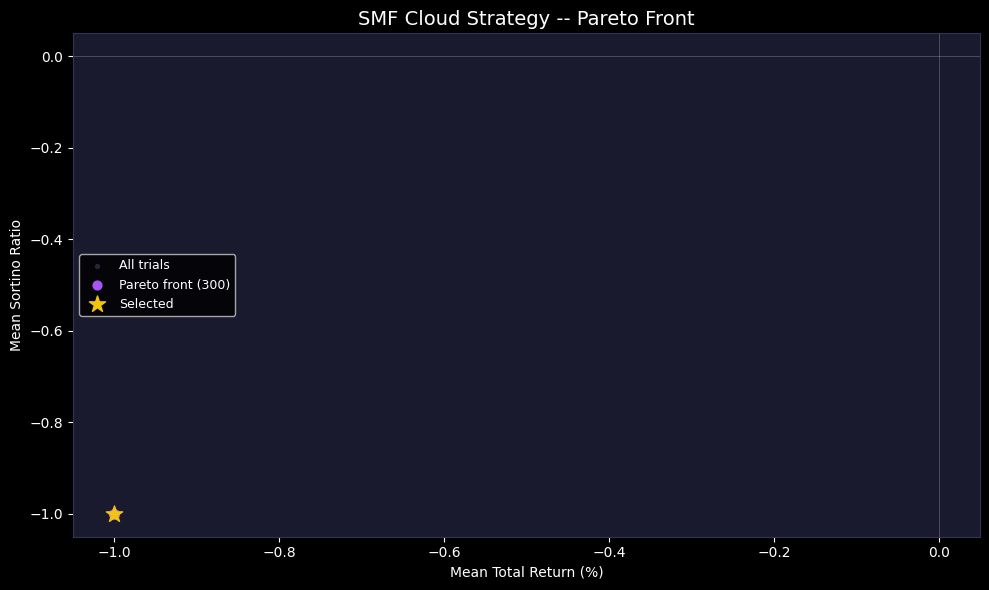

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

all_vals    = [(t.values[0], t.values[1]) for t in study_smf.trials
               if t.values and t.values[0] != -1.0]
pareto_vals = [(t.values[0], t.values[1]) for t in study_smf.best_trials]

ax.scatter([v[0] for v in all_vals],    [v[1] for v in all_vals],
           color='#4a4a6a', s=8, alpha=0.4, label='All trials')
ax.scatter([v[0] for v in pareto_vals], [v[1] for v in pareto_vals],
           color='#a855f7', s=40, zorder=5, label=f'Pareto front ({len(pareto_vals)})')
bx, by = best_trial.values
ax.scatter([bx], [by], color='#f1c40f', s=150, marker='*', zorder=6, label='Selected')
ax.axvline(0, color='white', lw=0.5, alpha=0.3)
ax.axhline(0, color='white', lw=0.5, alpha=0.3)
ax.set_xlabel('Mean Total Return (%)', color='white')
ax.set_ylabel('Mean Sortino Ratio',    color='white')
ax.set_title('SMF Cloud Strategy -- Pareto Front', color='white', fontsize=14)
ax.legend(fontsize=9)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')
plt.tight_layout()
plt.show()


## 8. Final Backtest — Optimised Parameters

In [ ]:
p = best_p

print('Running optimised SMF strategy ...')
entries_opt, exits_opt_smf, smf_opt = compute_smf_signals(
    open_, high, low, close, volume,
    trend_len    = p['trend_len'],
    basis_smooth = p['basis_smooth'],
    mf_len       = p['mf_len'],
    mf_smooth    = p['mf_smooth'],
    mf_power     = p['mf_power'],
    atr_len      = p['atr_len'],
    min_mult     = p['min_mult'],
    max_mult     = p['max_mult'],
    dot_cooldown = p['dot_cooldown'],
    entry_mode   = p['entry_mode'],
    min_strength = p['min_strength'],
    mf_positive  = p['mf_positive'],
)
atr_exits_opt, sl_stop_opt, lower_opt = compute_smf_exits(
    close, high, low, smf_opt,
    atr_multiplier    = p['atr_multiplier'],
    atr_period        = p['atr_period'],
    low_stop_lookback = p['low_stop_lookback'],
)
exits_opt = exits_opt_smf | atr_exits_opt

pf_opt = vbt.Portfolio.from_signals(
    close,
    entries   = entries_opt,
    exits     = exits_opt,
    sl_stop   = sl_stop_opt,
    freq      = '1D',
    init_cash = 100_000,
    fees      = 0.001,
    slippage  = 0.001,
)

sv_opt = pf_opt.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
so_opt = pf_opt.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
sv_bas = pf_base.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
so_bas = pf_base.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
print(f'Baseline   |  Sharpe mean={sv_bas.mean():.3f}  >1: {(sv_bas>1).sum()}/{len(sv_bas)}  |  Sortino={so_bas.mean():.3f}')
print(f'Optimised  |  Sharpe mean={sv_opt.mean():.3f}  >1: {(sv_opt>1).sum()}/{len(sv_opt)}  |  Sortino={so_opt.mean():.3f}')


## 9. Stats Comparison

In [ ]:
def pf_stats(label, pf):
    sr  = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so  = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    cm  = pf.calmar_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    tr  = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna() * 100
    mdd = pf.max_drawdown().replace([np.inf, -np.inf], np.nan).dropna() * 100
    wr  = pf.trades.win_rate().replace([np.inf, -np.inf], np.nan).dropna()
    nt  = pf.trades.count()
    return {
        'Strategy':         label,
        'Sharpe mean':      round(sr.mean(),  3),
        'Sharpe median':    round(sr.median(),3),
        'Sharpe > 0':       f'{(sr > 0).sum()}/{len(sr)}',
        'Sharpe > 1':       f'{(sr > 1).sum()}/{len(sr)}',
        'Sortino mean':     round(so.mean(),  3),
        'Calmar mean':      round(cm.mean(),  3),
        'Total Ret % mean': round(tr.mean(),  2),
        'Max DD % mean':    round(mdd.mean(), 2),
        'Win Rate mean':    round(wr.mean() * 100, 1),
        'Trades median':    int(nt.median()),
    }


stats_df = pd.DataFrame([
    pf_stats('Baseline (default)', pf_base),
    pf_stats('Optimised',          pf_opt),
]).set_index('Strategy').T

stats_df.style.set_properties(**{'text-align': 'right', 'font-size': '12px'})


## 10. Sharpe Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (label, pf, col) in zip(axes, [
    ('Baseline (default)', pf_base, '#95a5a6'),
    ('Optimised',          pf_opt,  '#a855f7'),
]):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=30, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='-',  label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0,           color='red',    lw=0.8, ls=':')
    ax.axvline(1,           color='lime',   lw=0.8, ls=':')
    ax.set_title(label, color='white')
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('SMF Cloud -- Sharpe Distribution (per symbol)', color='white', fontsize=13)
plt.tight_layout()
plt.show()


## 11. Top Symbols — Optimised Strategy

In [ ]:
N_TOP = 20

sr_opt = pf_opt.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
tr_opt = pf_opt.total_return().replace([np.inf, -np.inf], np.nan) * 100
top_syms = sr_opt.head(N_TOP).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.barh(top_syms[::-1], sr_opt[top_syms[::-1]], color='#a855f7', alpha=0.8)
ax.axvline(1, color='lime', lw=1, ls='--', label='Sharpe = 1')
ax.set_title(f'Top {N_TOP} by Sharpe (optimised)', color='white')
ax.set_xlabel('Sharpe Ratio', color='white')
ax.tick_params(colors='white')
ax.legend(fontsize=8)
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

ax = axes[1]
ax.set_facecolor('#1a1a2e')
tr_top = tr_opt[top_syms[::-1]]
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in tr_top]
ax.barh(top_syms[::-1], tr_top, color=colors, alpha=0.8)
ax.axvline(0, color='white', lw=0.8)
ax.set_title(f'Total Return % -- Top {N_TOP} (optimised)', color='white')
ax.set_xlabel('Total Return (%)', color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()


## 12. Single-Symbol Deep-Dive

In [ ]:
# Change SYMBOL to inspect any stock
SYMBOL       = sr_opt.index[0]   # default: best Sharpe symbol
LOOKBACK_DAYS = 500

smf_s  = smf_opt[SYMBOL]
c_sym  = close[SYMBOL].values
h_sym  = high[SYMBOL].values
l_sym  = low[SYMBOL].values
dates  = close.index

b_c    = smf_s['b_close'].values
b_o_v  = smf_s['b_open'].values
upper  = smf_s['upper'].values
lower_ = smf_s['lower'].values
mf_sm  = smf_s['mf_smooth'].values
str_sg = smf_s['strength_signed'].values
su     = smf_s['switch_up'].values.astype(bool)
sd     = smf_s['switch_down'].values.astype(bool)
bd     = smf_s['bull_dot'].values.astype(bool)
dd     = smf_s['bear_dot'].values.astype(bool)

n_show  = min(LOOKBACK_DAYS, len(dates))
sl_     = slice(-n_show, None)
dates_s = dates[sl_]
def s(arr): return arr[sl_]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor('#0f0f1a')

# Panel 1: Price + cloud
ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.plot(dates_s, s(c_sym), color='white', lw=1.0, zorder=3)
bull_mask = s(b_c) >= s(b_o_v)
ax.fill_between(dates_s, s(b_o_v), s(b_c),
                where=bull_mask,  color='#2ecc71', alpha=0.25, label='Bull cloud')
ax.fill_between(dates_s, s(b_o_v), s(b_c),
                where=~bull_mask, color='#e74c3c', alpha=0.25, label='Bear cloud')
ax.plot(dates_s, s(upper),  color='#3498db', lw=0.8, ls='--', alpha=0.6, label='Upper band')
ax.plot(dates_s, s(lower_), color='#e74c3c', lw=0.8, ls='--', alpha=0.6, label='Lower band')
ax.plot(dates_s, s(b_c),    color='#f39c12', lw=1.0, alpha=0.7, label='Basis')
ax.scatter(dates_s[s(su)], s(c_sym)[s(su)], marker='^', color='#2ecc71', s=80,  zorder=5, label='Switch Up')
ax.scatter(dates_s[s(sd)], s(c_sym)[s(sd)], marker='v', color='#e74c3c', s=80,  zorder=5, label='Switch Down')
ax.scatter(dates_s[s(bd)], s(l_sym)[s(bd)], marker='o', color='#1abc9c', s=40,  zorder=5, alpha=0.8, label='Bull retest')
ax.scatter(dates_s[s(dd)], s(h_sym)[s(dd)], marker='o', color='#e67e22', s=40,  zorder=5, alpha=0.8, label='Bear retest')
ax.set_title(f'{SYMBOL} -- SMF Cloud Strategy (last {n_show} bars)', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=7, ncol=4, loc='upper left')
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# Panel 2: Smart Money Flow
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
ax2.fill_between(dates_s, 0, s(mf_sm), where=s(mf_sm) >= 0, color='#2ecc71', alpha=0.5)
ax2.fill_between(dates_s, 0, s(mf_sm), where=s(mf_sm) <  0, color='#e74c3c', alpha=0.5)
ax2.axhline(0, color='white', lw=0.6, alpha=0.5)
ax2.set_ylabel('MF Smooth', color='white')
ax2.set_ylim(-1.05, 1.05)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

# Panel 3: Trend Strength
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')
ax3.fill_between(dates_s, 0, s(str_sg), where=s(str_sg) >= 0, color='#a855f7', alpha=0.6)
ax3.fill_between(dates_s, 0, s(str_sg), where=s(str_sg) <  0, color='#f39c12', alpha=0.5)
ax3.axhline(0, color='white', lw=0.6, alpha=0.5)
ax3.set_ylabel('Strength', color='white')
ax3.tick_params(colors='white')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax3.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()
print(f'Sharpe: {pf_opt.sharpe_ratio()[SYMBOL]:.3f}  |  Total Return: {pf_opt.total_return()[SYMBOL]*100:.1f}%')


## 13. Save Optimised Parameters

In [ ]:
h5_file = '../backend/assets/backtest_results_006.h5'

with pd.HDFStore(h5_file, mode='w') as store:
    pareto_rows = []
    for t in study_smf.best_trials:
        row = {'trial': t.number, 'total_return': t.values[0], 'sortino': t.values[1]}
        row.update(t.params)
        pareto_rows.append(row)
    store.put('pareto_front', pd.DataFrame(pareto_rows), format='table')

    best_row = {'trial': best_trial.number,
                'total_return': best_trial.values[0],
                'sortino':      best_trial.values[1]}
    best_row.update(best_p)
    store.put('best_params', pd.DataFrame([best_row]), format='table')

    store.put('sharpe_optimised',
              pf_opt.sharpe_ratio().replace([np.inf, -np.inf], np.nan),
              format='table')

print(f'Saved to {h5_file}')
print(f'  pareto_front: {len(pareto_rows)} trials')
print('  best_params:', best_p)
